In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import NMF
from wordcloud import WordCloud
import pickle

# Download required NLTK data
nltk.download('stopwords')

# Initialize stemmer
port_stem = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print("Loading dataset...")
dataset = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset", split="train")
df = dataset.to_pandas()
print(f"Dataset loaded: {len(df)} samples")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train_df.csv: 0.00B [00:00, ?B/s]

val_df.csv: 0.00B [00:00, ?B/s]

test_df.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/31232 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5205 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5206 [00:00<?, ? examples/s]

Dataset loaded: 31232 samples
Sentiment distribution:
sentiment
neutral     11649
positive    10478
negative     9105
Name: count, dtype: int64


In [ ]:
def converttolowercase(text):
    return text.lower()

def removenumbers(text):
    return re.sub(r'\d+', '', text)

def removepunctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

def removeextraspaces(text):
    return ' '.join(text.split())

def textcleaning(text):
    text = converttolowercase(text)
    text = removenumbers(text)
    text = removepunctuation(text)
    text = removeextraspaces(text)
    return text

In [ ]:
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content
                      if word not in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

print("Preprocessing text...")
df['cleanedtext'] = df['text'].apply(stemming)
print("Text preprocessing complete!")

Preprocessing text...
Text preprocessing complete!


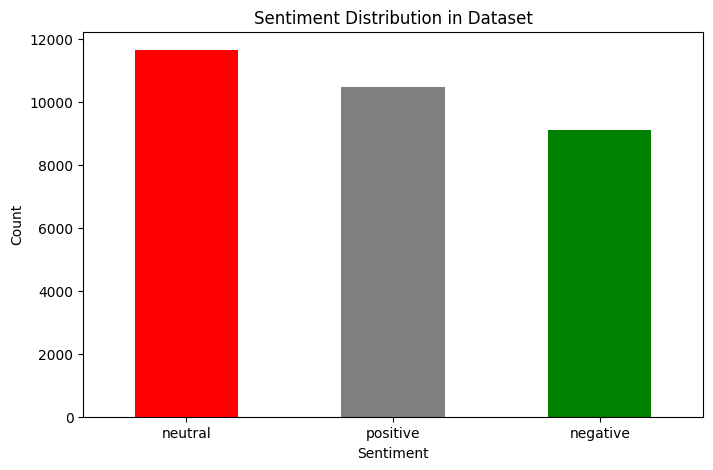

In [ ]:
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print("Creating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleanedtext'].values)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Creating TF-IDF features...
TF-IDF matrix shape: (31232, 5000)


In [ ]:
print("Training SVM classifier...")
X = tfidf_matrix
y = df['sentiment']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train LinearSVC
svm_model = LinearSVC(max_iter=10000, random_state=42)
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_val)

# Evaluate
print(f"\nAccuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Training SVM classifier...

Accuracy: 0.6355

Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.61      0.62      1821
     neutral       0.58      0.60      0.59      2330
    positive       0.70      0.70      0.70      2096

    accuracy                           0.64      6247
   macro avg       0.64      0.64      0.64      6247
weighted avg       0.64      0.64      0.64      6247



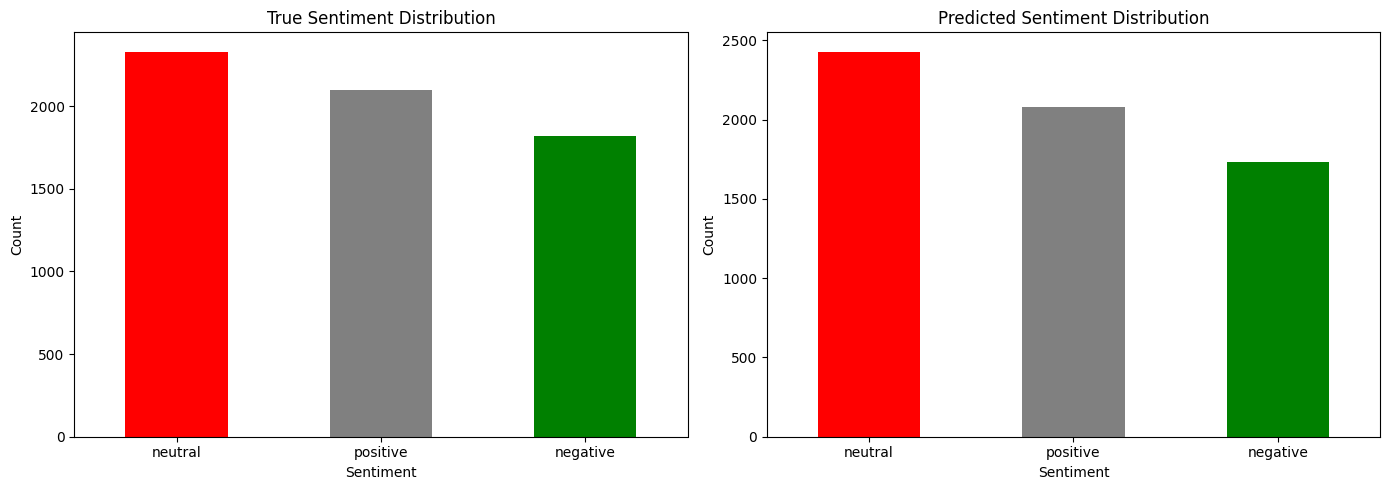

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_val).value_counts().plot(kind='bar', ax=axes[0],
                                      color=['red', 'gray', 'green'])
axes[0].set_title('True Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

pd.Series(y_pred).value_counts().plot(kind='bar', ax=axes[1],
                                       color=['red', 'gray', 'green'])
axes[1].set_title('Predicted Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Training SGDClassifier for loss visualization...


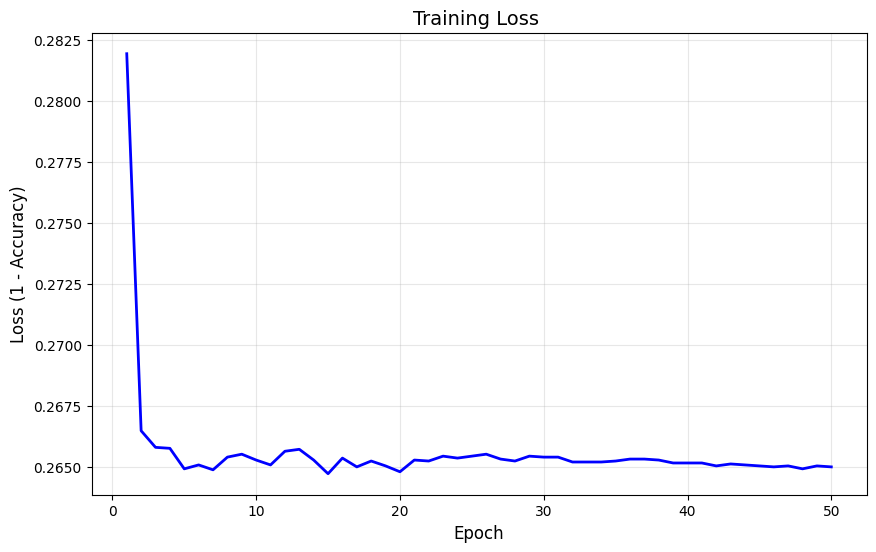

Final SGD Validation Accuracy: 0.6626


In [ ]:
print("Training SGDClassifier for loss visualization...")
sgd_model = SGDClassifier(loss='hinge', max_iter=1, warm_start=True, random_state=42)

losses = []
n_epochs = 50

for epoch in range(n_epochs):
    sgd_model.partial_fit(X_train, y_train, classes=np.unique(y))
    y_pred_train = sgd_model.predict(X_train)
    loss = 1 - accuracy_score(y_train, y_pred_train)
    losses.append(loss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), losses, 'b-', linewidth=2)
plt.title('Training Loss ', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (1 - Accuracy)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final SGD Validation Accuracy: {accuracy_score(y_val, sgd_model.predict(X_val)):.4f}")

In [ ]:
print("="*120)
print(f"{'Text':<80} {'True Sentiment':<15} {'Predicted Sentiment'}")
print("="*120)

for i in range(10):
    text = df.iloc[y_val.index[i]]['text']
    true_label = y_val.iloc[i]
    pred_label = y_pred[i]
    print(f"{text[:75]:<80} {str(true_label):<15} {pred_label}")

Text                                                                             True Sentiment  Predicted Sentiment
Happy Mommy`s Dad Mommy  watching the football  Yay The Eagles Are WINNINGG      positive        positive
 I walk to & from work...about 25 mins...think that makes it worse   Improv      neutral         neutral
 now I know why it didn`t work, just not too keen on paying though for a 2n      neutral         positive
Trying to decide on a movie with the friends.. not going to well! lol :p  N      negative        neutral
Less rain more sunshine                                                          neutral         neutral
Jay Leno has one more show left as the host of The Tonight Show                  neutral         neutral
Update: dropped 5 star rating to 1star. App will not sync. I have it on And      negative        positive
If time tracking was added and the parser/interface of the "what would you       neutral         positive
pretty bummed that it had to rain last 

In [ ]:
print("Performing topic modeling...")
num_topics = 5
nmf_model = NMF(n_components=num_topics, random_state=42)
nmf_model.fit(tfidf_matrix)

feature_names = tfidf_vectorizer.get_feature_names_out()

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx + 1}:")
        top_features_ind = topic.argsort()[:-no_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_weights = topic[top_features_ind]
        for word, weight in zip(top_features, top_weights):
            print(f"{word} ({weight:.2f})", end=" ")
        print()

print("\nExtracted Topics:")
display_topics(nmf_model, feature_names, 10)

Performing topic modeling...

Extracted Topics:

Topic 1:
app (3.39) use (1.69) task (1.13) great (1.00) time (0.79) like (0.78) help (0.63) list (0.63) calendar (0.61) remind (0.57) 

Topic 2:
day (2.60) mother (1.97) happi (1.88) mom (0.58) mommi (0.19) war (0.14) mum (0.14) today (0.14) wish (0.14) hope (0.13) 

Topic 3:
good (3.56) morn (0.70) night (0.33) feel (0.22) luck (0.19) hope (0.18) realli (0.13) day (0.13) pretti (0.12) bad (0.11) 

Topic 4:
work (3.45) today (0.23) time (0.20) tomorrow (0.16) got (0.15) home (0.15) weekend (0.14) hour (0.14) notif (0.10) im (0.10) 

Topic 5:
love (1.98) thank (1.38) http (1.04) com (0.93) miss (0.65) know (0.59) twitpic (0.55) lol (0.48) like (0.43) got (0.35) 


Generating word clouds for topics...


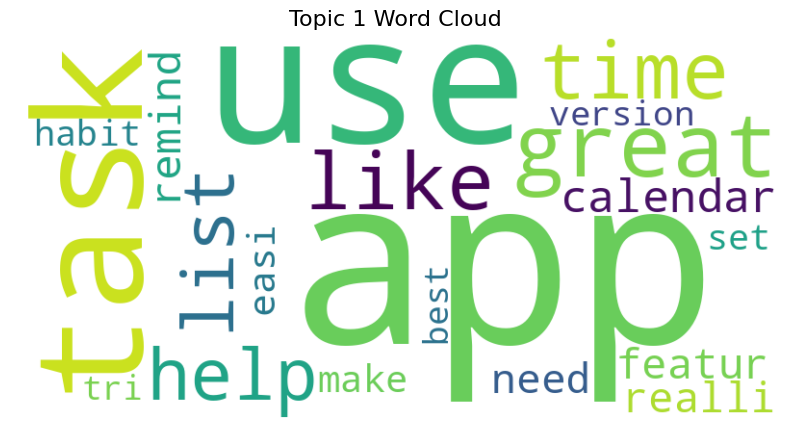

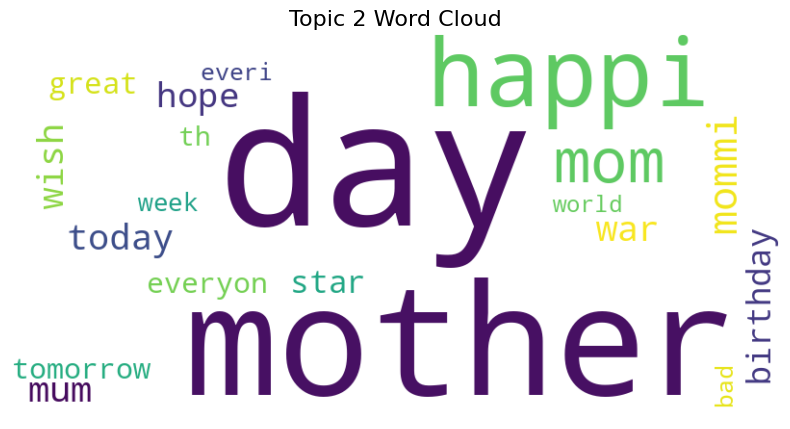

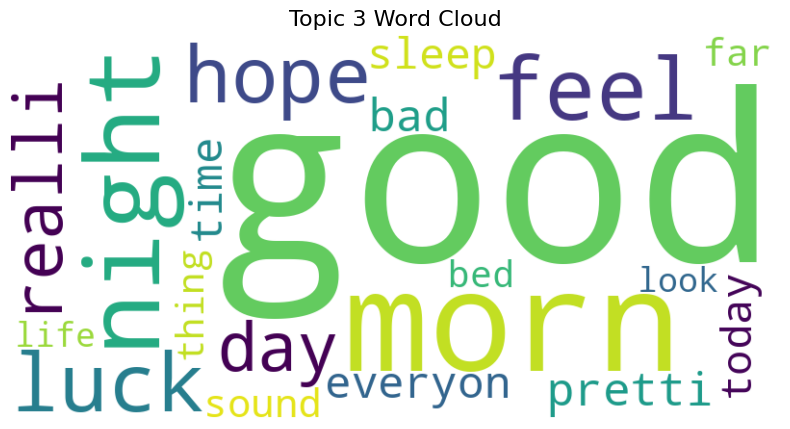

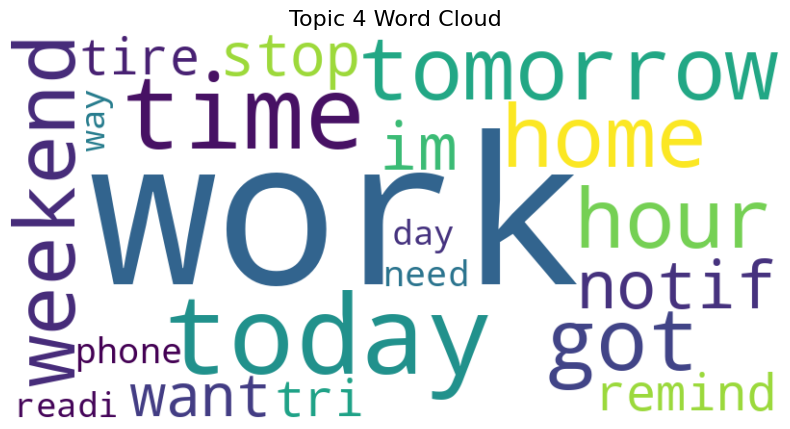

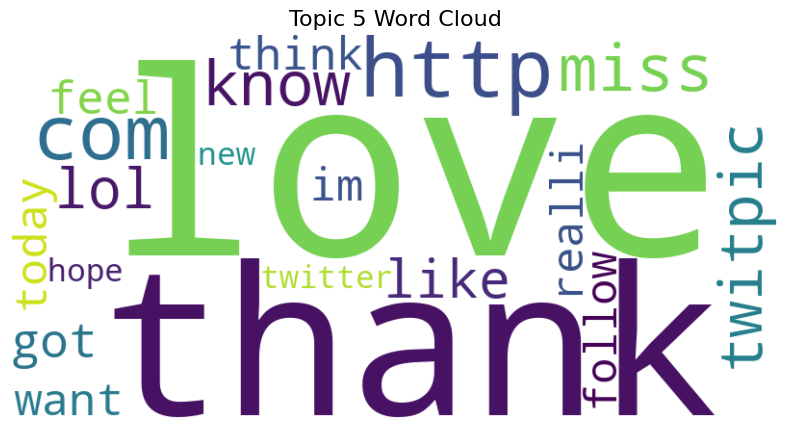

In [ ]:
def plot_topic_wordcloud(model, feature_names, topic_idx):
    topic = model.components_[topic_idx]
    word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[-20:]}

    wordcloud = WordCloud(width=800, height=400,
                         background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {topic_idx + 1} Word Cloud', fontsize=16)
    plt.axis('off')
    plt.show()

print("Generating word clouds for topics...")
for i in range(num_topics):
    plot_topic_wordcloud(nmf_model, feature_names, i)

In [ ]:
print("Saving models...")
with open('svm_sentiment_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("Models saved successfully!")

Saving models...
Models saved successfully!


In [ ]:
def predict_sentiment(text):
    cleaned = stemming(text)
    vector = tfidf_vectorizer.transform([cleaned])
    prediction = svm_model.predict(vector)[0]
    return prediction

# Test with example
test_text = "I hate this app! It's dull and very boring."
print(f"Test Prediction:")
print(f"Input: {test_text}")
print(f"Predicted Sentiment: {predict_sentiment(test_text)}")

Test Prediction:
Input: I hate this app! It's dull and very boring.
Predicted Sentiment: negative
